# Notebook 06 — Citation Surface Analysis

Experimento determinístico sobre a superfície das citações do dataset corrente. O escopo é deliberadamente limitado a **detecção** (encontrar trechos candidatos) e **parsing** (estruturar trechos já conhecidos). **Resolução** — ligar uma citação a um registro canônico — fica explicitamente fora deste notebook.

O notebook não altera o parser estrutural, não usa `CaseIndex`, não cria componentes de produção e não produz submissões.

## 1. Dados e contrato explorado

São usados exclusivamente `material_desafio_jusbrasil_bracis/goldenset.xlsx` e os arquivos `txt/*.txt` da revisão corrente. O diretório histórico `_old` não participa desta análise.

In [1]:
from __future__ import annotations

import hashlib
import re
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.max_rows', 30)

DATASET_CANDIDATES = (Path('material_desafio_jusbrasil_bracis'), Path('../material_desafio_jusbrasil_bracis'))
DATASET_DIR = next((path for path in DATASET_CANDIDATES if path.is_dir()), None)
if DATASET_DIR is None:
    raise FileNotFoundError('Dataset corrente não encontrado.')

GOLDENSET_PATH = DATASET_DIR / 'goldenset.xlsx'
TEXT_DIR = DATASET_DIR / 'txt'
DB_PATH = DATASET_DIR / 'desafio1_bracis.db'
assert GOLDENSET_PATH.is_file() and TEXT_DIR.is_dir() and DB_PATH.is_file()

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

db_sha_before = sha256_file(DB_PATH)
print(f'Dataset: {DATASET_DIR.resolve()}')
print(f'SHA-256 do SQLite (antes): {db_sha_before}')


Dataset: /home/guto/Development/python/bracis_jusbrasil/material_desafio_jusbrasil_bracis
SHA-256 do SQLite (antes): d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71


In [2]:
gold = pd.read_excel(GOLDENSET_PATH, sheet_name='goldenset', engine='openpyxl')
required_columns = {'nivel', 'documento_id', 'citacao_id', 'inicio', 'fim', 'trecho', 'tipo', 'classificacao', 'id_canonico'}
missing_columns = required_columns - set(gold.columns)
assert not missing_columns, f'Colunas ausentes: {missing_columns}'

texts = {path.stem: path.read_text(encoding='utf-8') for path in sorted(TEXT_DIR.glob('*.txt'))}
assert len(texts) == 26, f'Esperados 26 textos; encontrados {len(texts)}.'

citations = gold.copy().reset_index(names='gold_idx')
citations['nivel'] = 'N' + citations['nivel'].astype(str).str.upper().str.removeprefix('N')
citations['inicio'] = citations['inicio'].astype(int)
citations['fim'] = citations['fim'].astype(int)
citations['texto_documento'] = citations['documento_id'].map(texts)
assert citations['texto_documento'].notna().all(), 'Há documentos do goldenset sem .txt correspondente.'
citations['trecho_esperado'] = citations['trecho'].astype(str).str.replace(r'\n', '\n', regex=False)
citations['span_text'] = citations.apply(lambda row: row.texto_documento[row.inicio:row.fim], axis=1)
citations['span_length'] = citations['fim'] - citations['inicio']

assert len(citations) == 225
display(citations.head(3))


,gold_idx,nivel,documento_id,citacao_id,inicio,fim,trecho,tipo,classificacao,id_canonico,texto_documento,trecho_esperado,span_text,span_length
0,0,N1,gen_n1_001,g1,469,498,normas\nde regência da matéria,lei,incompleta,NaN,DEFENSORIA PÚBLICA DA UNIÃO\nOFÍCIO JUNTO AO SUPERIOR TRIBUNAL MILITAR\n\nProcesso nº 1292746-27.2020.7.13.1173\nAssistido: TRANSPORTES ...,normas\nde regência da matéria,normas\nde regência da matéria,29
1,1,N1,gen_n1_001,g2,589,652,julgado do STF proferido em 2024 pela relatoria de Dias Toffoli,jurisprudencia,incompleta,NaN,DEFENSORIA PÚBLICA DA UNIÃO\nOFÍCIO JUNTO AO SUPERIOR TRIBUNAL MILITAR\n\nProcesso nº 1292746-27.2020.7.13.1173\nAssistido: TRANSPORTES ...,julgado do STF proferido em 2024 pela relatoria de Dias Toffoli,julgado do STF proferido em 2024 pela relatoria de Dias Toffoli,63
2,2,N1,gen_n1_001,g3,797,820,Reclamação nº 66.516/RO,jurisprudencia,inventada,NaN,DEFENSORIA PÚBLICA DA UNIÃO\nOFÍCIO JUNTO AO SUPERIOR TRIBUNAL MILITAR\n\nProcesso nº 1292746-27.2020.7.13.1173\nAssistido: TRANSPORTES ...,Reclamação nº 66.516/RO,Reclamação nº 66.516/RO,23


## 2. Validação dos spans

Antes de medir qualquer regra, cada intervalo `[inicio:fim]` é confrontado com o `trecho` do goldenset. Esta é uma checagem do contrato de anotação, não uma avaliação de resolução.

In [3]:
citations['span_match'] = citations['span_text'].eq(citations['trecho_esperado'])
span_summary = citations['span_match'].value_counts().rename_axis('span_match').reset_index(name='quantidade')
display(span_summary)
mismatches = citations.loc[~citations['span_match'], ['documento_id', 'citacao_id', 'inicio', 'fim', 'trecho_esperado', 'span_text']]
display(mismatches)
assert citations['span_match'].all(), 'Há offsets incompatíveis com os textos correntes.'
print(f'{len(citations)} spans validados; {len(mismatches)} divergências.')


,span_match,quantidade
0,True,225


,documento_id,citacao_id,inicio,fim,trecho_esperado,span_text


225 spans validados; 0 divergências.


## 3. Visão geral e contexto

A distribuição de nível, classe e tipo descreve o conjunto anotado; ela não participa da definição de famílias nem das regras de detecção.

,nivel,quantidade
0,N1,116
1,N2,109


,classificacao,quantidade
0,real,96
1,incompleta,65
2,inventada,64


,tipo,quantidade
0,jurisprudencia,186
1,lei,39


,documento_id,citacao_id,nivel,tipo,contexto
161,gen_n2_006,g6,N2,jurisprudencia,"duta ao pleito. Antes de avançar, convérn delimitar o objeto da irresignação.\nNão se pode ignorar a <CITAÇÃO>Reclamação do STF, de 2020..."
9,gen_n1_001,g10,N1,jurisprudencia,idêntica à destes autos. Nem se diga que a hipótese comportaria distinção. Como já se reconheceu\nno <CITAÇÃO>RSE nº 7000592-58.2025.7.0...
124,gen_n2_002,g1,N2,jurisprudencia,".\n\n\nA doutrina especializada acompanha, sem divergência relevante, esse entendimento. Ao ãpreciar\no <CITAÇÃO>acórdão do STJ julgado ..."
157,gen_n2_006,g2,N2,lei,ão equivalente. A parte contrária limita-se a repisar\nargumentos já superados. Nos exatos termos do <CITAÇÃO>art 276 do Código Eleitora...
68,gen_n1_008,g8,N1,jurisprudencia,r. A moldura fática delineada na origem é suficiente para o deslinde da causa.\nAmpara a pretensão a <CITAÇÃO>orientação jurisprudencial...
112,gen_n1_013,g5,N1,jurisprudencia,observar\nque a orientação dos tribunais superiores é firme no ponto. A parte recorrente apoia-se no <CITAÇÃO>julgado\ndo TSE proferido ...
160,gen_n2_006,g5,N2,jurisprudencia,". Sob outro ângulo, a solução adotada na origem afronta a segurança jurídica.\nNão se pode ignorar o <CITAÇÃO>AgR-AI 0603026-69201860900..."
14,gen_n1_002,g5,N1,jurisprudencia,"\nsolar quanto ao ponto ora debatido. Não se trata, aqui, de revolver matéria fática. Vale invocar\no <CITAÇÃO>AgInt no AREsp nº 1.996.4..."
201,gen_n2_011,g4,N2,jurisprudencia,"osteriores.\nAntes de avãnçar, convém delimitar o objeto da irresignação. Milita em favor da parte o\n<CITAÇÃO>Temã 2.680 da repercussão..."
109,gen_n1_013,g2,N1,jurisprudencia,leitura\nconjunta dos dispositivos invocados conduz à mesma conclusão. Nesse exato sentido caminha a\n<CITAÇÃO>Reclamação nº 22.225/SP</...


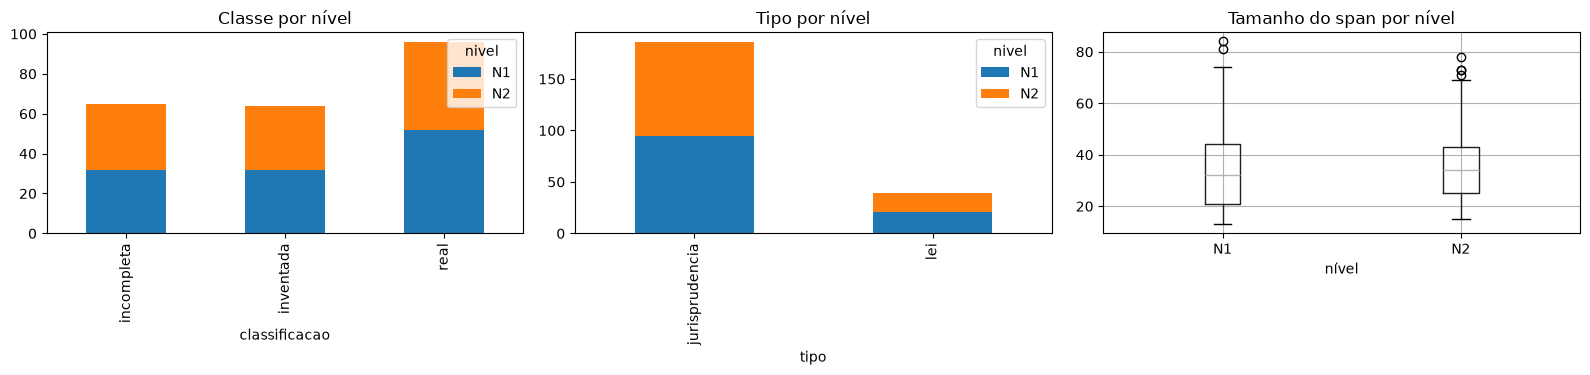

In [4]:
def counts_table(column: str) -> pd.DataFrame:
    return citations[column].value_counts().rename_axis(column).reset_index(name='quantidade')

display(counts_table('nivel'))
display(counts_table('classificacao'))
display(counts_table('tipo'))
assert citations['nivel'].value_counts().to_dict() == {'N1': 116, 'N2': 109}
assert citations['classificacao'].value_counts().to_dict() == {'real': 96, 'incompleta': 65, 'inventada': 64}
assert citations['tipo'].value_counts().to_dict() == {'jurisprudencia': 186, 'lei': 39}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pd.crosstab(citations['classificacao'], citations['nivel']).plot(kind='bar', stacked=True, ax=axes[0], title='Classe por nível')
pd.crosstab(citations['tipo'], citations['nivel']).plot(kind='bar', stacked=True, ax=axes[1], title='Tipo por nível')
citations.boxplot(column='span_length', by='nivel', ax=axes[2])
axes[2].set_title('Tamanho do span por nível')
axes[2].set_xlabel('nível')
fig.suptitle('')
fig.tight_layout()

def context_with_marker(row: pd.Series, margin: int = 100) -> str:
    text = row['texto_documento']
    before = text[max(0, row['inicio'] - margin):row['inicio']]
    after = text[row['fim']:min(len(text), row['fim'] + margin)]
    return f'{before}<CITAÇÃO>{row["span_text"]}</CITAÇÃO>{after}'

contexts = citations.sample(min(12, len(citations)), random_state=20260828).copy()
contexts['contexto'] = contexts.apply(context_with_marker, axis=1)
display(contexts[['documento_id', 'citacao_id', 'nivel', 'tipo', 'contexto']])


## 4. Taxonomia de famílias observáveis

A taxonomia abaixo usa somente a forma textual e o tipo fornecido no contrato. Cada citação recebe exatamente uma família; `real`, `inventada` e `incompleta` são mantidos apenas para análise posterior.

,family,count,N1,N2,real,inventada,incompleta
2,processo_ou_recurso_numerado,85,46,39,42,32,11
6,jurisprudencia_referencia_geral,46,15,31,13,10,23
5,lei_dispositivo_com_diploma,27,13,14,13,14,0
3,processo_cnj,25,17,8,23,2,0
1,jurisprudencia_tribunal_contextual,20,11,9,0,0,20
0,lei_referencia_geral,11,7,4,0,0,11
4,sumula_numerada,10,6,4,4,6,0
7,lei_dispositivo_sem_diploma,1,1,0,1,0,0


,family,nivel,documento_id,citacao_id,span_text
20,jurisprudencia_referencia_geral,N1,gen_n1_003,g2,jurisprudência pacífica desta Corte
23,jurisprudencia_referencia_geral,N1,gen_n1_003,g5,entendimento sumulado sobre a matéria
125,jurisprudencia_referencia_geral,N2,gen_n2_002,g2,5úmula 211 do STJ
128,jurisprudencia_referencia_geral,N2,gen_n2_002,g5,AgREsp Nº 84690 - MG
1,jurisprudencia_tribunal_contextual,N1,gen_n1_001,g2,julgado do STF proferido em 2024 pela relatoria de Dias Toffoli
4,jurisprudencia_tribunal_contextual,N1,gen_n1_001,g5,julgado do STM proferido em 2023\npela relatoria de CARLOS AUGUSTO AMARAL OLIVEIRA
121,jurisprudencia_tribunal_contextual,N2,gen_n2_001,g6,julgado do STJ proferido em 2023 pela relatoria dc Sérgio Kukinã
124,jurisprudencia_tribunal_contextual,N2,gen_n2_002,g1,acórdão do STJ julgado em 2021 sob relatoria de Assusete Magalhães
18,lei_dispositivo_com_diploma,N1,gen_n1_002,g9,art. 1.134 da Lei nº\n13.105/2015
21,lei_dispositivo_com_diploma,N1,gen_n1_003,g3,art. 158 do Código de Defesa do Consumidor


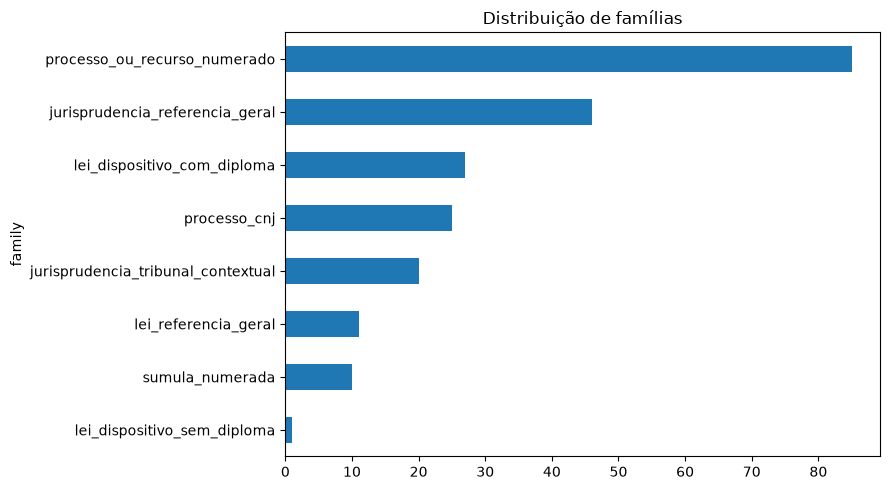

In [5]:
CNJ_RE = re.compile(r'\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b')
TRIBUNAL_RE = re.compile(r'\b(?:STF|STJ|TSE|TST|STM|Supremo Tribunal Federal|Superior Tribunal de Justiça|Tribunal Superior Eleitoral|Tribunal Superior do Trabalho)\b', re.I)
PROCESS_CLASS_RE = re.compile(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b', re.I)
SUMULA_RE = re.compile(r'\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+', re.I)
ARTICLE_RE = re.compile(r'\b(?:art(?:igo)?[.]?\s*\d+|§\s*\d+|inciso\s+[IVXLCDM]+)', re.I)
DIPLOMA_RE = re.compile(r'\b(?:Constituiç[aã]o|C[oó]digo|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+|CLT|CPC|CPP|CC|CDC|CPM)\b', re.I)

def citation_family(text: str, citation_type: str) -> str:
    if citation_type == 'lei':
        if ARTICLE_RE.search(text) and DIPLOMA_RE.search(text):
            return 'lei_dispositivo_com_diploma'
        if ARTICLE_RE.search(text):
            return 'lei_dispositivo_sem_diploma'
        return 'lei_referencia_geral'
    if SUMULA_RE.search(text):
        return 'sumula_numerada'
    if re.search(r'\bS[ÚU]MULA\b', text, re.I):
        return 'sumula_sem_numero'
    if CNJ_RE.search(text):
        return 'processo_cnj'
    if PROCESS_CLASS_RE.search(text) and re.search(r'\d', text):
        return 'processo_ou_recurso_numerado'
    if TRIBUNAL_RE.search(text) and (re.search(r'\b20\d{2}\b', text) or re.search(r'Relator|Relatora|ministro|ministra', text, re.I)):
        return 'jurisprudencia_tribunal_contextual'
    return 'jurisprudencia_referencia_geral'

citations['family'] = citations.apply(lambda row: citation_family(row['span_text'], row['tipo']), axis=1)
assert citations['family'].notna().all() and len(citations['family']) == len(citations)
family_summary = (citations.groupby('family', sort=False).agg(count=('gold_idx', 'size'), N1=('nivel', lambda s: (s == 'N1').sum()), N2=('nivel', lambda s: (s == 'N2').sum()), real=('classificacao', lambda s: (s == 'real').sum()), inventada=('classificacao', lambda s: (s == 'inventada').sum()), incompleta=('classificacao', lambda s: (s == 'incompleta').sum())).reset_index())
display(family_summary.sort_values('count', ascending=False))
family_summary.sort_values('count').plot.barh(x='family', y='count', legend=False, figsize=(9, 5), title='Distribuição de famílias')
plt.tight_layout()

family_examples = (citations.sort_values(['family', 'nivel', 'documento_id', 'inicio']).groupby(['family', 'nivel'], group_keys=False).head(2)[['family', 'nivel', 'documento_id', 'citacao_id', 'span_text']])
display(family_examples)


## 5. Níveis N1/N2 e ruído contextual

As características abaixo descrevem indícios de formatação e ruído dentro dos próprios spans. Um token alfanumérico é apenas marcado quando há contexto de identificador; nenhuma correção OCR é aplicada.

In [6]:
def n2_noise_categories(text: str) -> list[str]:
    categories = []
    if '\n' in text:
        categories.append('quebra_de_linha_interna')
    if re.search(r' {2,}', text):
        categories.append('espacos_multiplos')
    if re.search(r'\d\s+\d|\d[.,/-]\s+\d', text):
        categories.append('separador_degradado_em_numero')
    if re.search(r'\b[A-Z]\s+[A-Z]\b', text):
        categories.append('sigla_fragmentada')
    identifier_tokens = re.findall(r'\b[A-Z0-9]{5,}\b', text.upper())
    if any(re.search(r'\d', token) and re.search(r'[OILS]', token) for token in identifier_tokens):
        categories.append('token_identificador_alfa_numerico')
    return categories or ['sem_indicio_de_ruido']

citations['numero_tokens'] = citations['span_text'].str.count(r'\d+')
citations['tem_quebra_linha'] = citations['span_text'].str.contains('\n')
citations['tem_espacos_multiplos'] = citations['span_text'].str.contains(r' {2,}')
citations['tem_pontuacao_numerica'] = citations['span_text'].str.contains(r'\d[./-]\d')
citations['tem_tribunal'] = citations['span_text'].str.contains(TRIBUNAL_RE)
citations['tem_classe_processual'] = citations['span_text'].str.contains(PROCESS_CLASS_RE)
citations['tem_uf'] = citations['span_text'].str.contains(r'[-/]\s*[A-Z]{2}\b')
citations['tem_relator'] = citations['span_text'].str.contains(r'Relator|Relatora|ministro|ministra', case=False, regex=True)
citations['tem_ano'] = citations['span_text'].str.contains(r'\b20\d{2}\b')
citations['ruido_n2'] = citations['span_text'].map(n2_noise_categories)
feature_columns = ['span_length', 'numero_tokens', 'tem_quebra_linha', 'tem_espacos_multiplos', 'tem_pontuacao_numerica', 'tem_tribunal', 'tem_classe_processual', 'tem_uf', 'tem_relator', 'tem_ano']
display(citations.groupby('nivel')[feature_columns].mean().round(3))
n2_noise = citations.loc[citations['nivel'].eq('N2'), ['documento_id', 'citacao_id', 'span_text', 'ruido_n2']].explode('ruido_n2')
display(n2_noise['ruido_n2'].value_counts().rename_axis('categoria').reset_index(name='quantidade'))
display(n2_noise.loc[~n2_noise['ruido_n2'].eq('sem_indicio_de_ruido')].head(20))


,span_length,numero_tokens,tem_quebra_linha,tem_espacos_multiplos,tem_pontuacao_numerica,tem_tribunal,tem_classe_processual,tem_uf,tem_relator,tem_ano
nivel,,,,,,,,,,
N1,34.664,2.155,0.198,0.000,0.509,0.181,0.448,0.491,0.095,0.293
N2,35.679,1.890,0.330,0.119,0.339,0.220,0.394,0.312,0.083,0.266


,categoria,quantidade
0,sem_indicio_de_ruido,56
1,quebra_de_linha_interna,36
2,espacos_multiplos,13
3,separador_degradado_em_numero,11
4,token_identificador_alfa_numerico,2


,documento_id,citacao_id,span_text,ruido_n2
116,gen_n2_001,g1,RE nº 5. 230.808-DF,separador_degradado_em_numero
118,gen_n2_001,g3,"Reclamação\ndo STF, de 2024, Rel. Min. Cármen Lúcia",quebra_de_linha_interna
120,gen_n2_001,g5,Súmula 935\ndo STF,quebra_de_linha_interna
123,gen_n2_001,g8,EDcl nos EDcl no AgInt no Agravo em Recurso Especial No 1145207 – SP,espacos_multiplos
127,gen_n2_002,g4,julgado do STJ proferido em\n2023 pela relatoria de Assusete Magãlhães,quebra_de_linha_interna
128,gen_n2_002,g5,AgREsp Nº 84690 - MG,espacos_multiplos
129,gen_n2_002,g6,"artigo 93, IX, da Constituição\nda República",quebra_de_linha_interna
130,gen_n2_002,g7,Rec. Esp. No 1.880.529\n- SP,quebra_de_linha_interna
131,gen_n2_003,g1,"precedente do STF\nde 2024, da relatoria de Cármen Lúcia",quebra_de_linha_interna
136,gen_n2_003,g6,jurisprudência\nconsolidada dos tribunais superiores,quebra_de_linha_interna


## 6. Baseline experimental de detecção

As regras são pequenas e legíveis. Cada candidato registra offsets, texto, regra e família. A deduplicação remove apenas candidatos com o mesmo documento e intervalo; sobreposições continuam visíveis como possível ambiguidade de fronteira.

In [7]:
PROCESS_RE = re.compile(r'\b(?:(?:AgInt|AgRg|EDcl|ED)\s+(?:no|n[oº.]+)\s+)?(?:AREsp|REsp|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Recurso\s+(?:Especial|Extraordin[aá]rio)|Agravo(?:\s+Regimental)?|Habeas\s+Corpus|Reclamaç[aã]o)\s*(?:n[ºo.]?\s*)?\d[\d.\-/ ]{2,}\d(?:\s*-\s*[A-Z]{2})?', re.I)
SUMULA_DETECT_RE = re.compile(r'\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+', re.I)
LAW_WITH_DIPLOMA_RE = re.compile(r'\b(?:art(?:igo)?[.]?\s*\d+(?:[ºo])?(?:\s*,?\s*§\s*\d+(?:[ºo])?)?)(?:\s+do|\s+da)?\s+(?:Constituiç[aã]o(?: Federal)?|C[oó]digo [A-Za-zÀ-ÿ ]+|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+[./-]?[\d./-]*)', re.I)
ARTICLE_DETECT_RE = re.compile(r'\b(?:art(?:igo)?[.]?\s*\d+(?:[ºo])?|§\s*\d+(?:[ºo])?)', re.I)
COURT_CONTEXT_RE = re.compile(r'\b(?:STF|STJ|TSE|TST|STM)\b[^\n]{0,100}\b(?:20\d{2}|Relator|Relatora)\b', re.I)

RULES = (
    ('cnj', CNJ_RE, 'jurisprudencia'),
    ('processo_ou_recurso', PROCESS_RE, 'jurisprudencia'),
    ('sumula_numerada', SUMULA_DETECT_RE, 'jurisprudencia'),
    ('lei_com_diploma', LAW_WITH_DIPLOMA_RE, 'lei'),
    ('dispositivo_legal', ARTICLE_DETECT_RE, 'lei'),
    ('tribunal_contextual', COURT_CONTEXT_RE, 'jurisprudencia'),
)

def detect_candidates(doc_id: str, text: str) -> list[dict]:
    candidates = []
    for rule, pattern, candidate_type in RULES:
        for match in pattern.finditer(text):
            candidate_text = match.group(0)
            candidates.append({'documento_id': doc_id, 'inicio': match.start(), 'fim': match.end(), 'text': candidate_text, 'rule': rule, 'tipo': candidate_type, 'family': citation_family(candidate_text, candidate_type)})
    return candidates

def deduplicate_candidates(records: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
    unique, duplicates = {}, []
    for record in sorted(records, key=lambda item: (item['documento_id'], item['inicio'], item['fim'], item['rule'])):
        key = (record['documento_id'], record['inicio'], record['fim'])
        if key in unique:
            duplicates.append({**record, 'kept_rule': unique[key]['rule']})
        else:
            unique[key] = record
    return pd.DataFrame(unique.values()), pd.DataFrame(duplicates)

raw_candidates = [candidate for doc_id, text in texts.items() for candidate in detect_candidates(doc_id, text)]
predictions, exact_duplicates = deduplicate_candidates(raw_candidates)
predictions = predictions.reset_index(names='pred_idx')
predictions['nivel'] = predictions['documento_id'].map(citations.drop_duplicates('documento_id').set_index('documento_id')['nivel'])

overlaps = []
for doc_id, group in predictions.groupby('documento_id'):
    for left, right in combinations(group.to_dict('records'), 2):
        if max(left['inicio'], right['inicio']) < min(left['fim'], right['fim']):
            overlaps.append({'documento_id': doc_id, 'left_rule': left['rule'], 'right_rule': right['rule'], 'left_text': left['text'], 'right_text': right['text']})

print(f'Candidatos brutos: {len(raw_candidates)}; após deduplicação exata: {len(predictions)}; duplicatas exatas: {len(exact_duplicates)}; pares sobrepostos: {len(overlaps)}')
display(predictions.head(20))
display(pd.DataFrame(overlaps).head(20))


Candidatos brutos: 194; após deduplicação exata: 194; duplicatas exatas: 0; pares sobrepostos: 22


,pred_idx,documento_id,inicio,fim,text,rule,tipo,family,nivel
0,0,gen_n1_001,83,108,1292746-27.2020.7.13.1173,cnj,jurisprudencia,processo_cnj,N1
1,1,gen_n1_001,600,621,STF proferido em 2024,tribunal_contextual,jurisprudencia,jurisprudencia_tribunal_contextual,N1
2,2,gen_n1_001,797,817,Reclamação nº 66.516,processo_ou_recurso,jurisprudencia,processo_ou_recurso_numerado,N1
3,3,gen_n1_001,957,982,7557430-50.2018.7.00.0000,cnj,jurisprudencia,processo_cnj,N1
4,4,gen_n1_001,1409,1430,STM proferido em 2023,tribunal_contextual,jurisprudencia,jurisprudencia_tribunal_contextual,N1
5,5,gen_n1_001,1935,1960,7000449-40.2023.7.00.0000,cnj,jurisprudencia,processo_cnj,N1
6,6,gen_n1_001,2901,2911,Rcl 88.178,processo_ou_recurso,jurisprudencia,processo_ou_recurso_numerado,N1
7,7,gen_n1_001,3072,3083,STM de 2023,tribunal_contextual,jurisprudencia,jurisprudencia_tribunal_contextual,N1
8,8,gen_n1_001,3259,3284,7000592-58.2025.7.00.0000,cnj,jurisprudencia,processo_cnj,N1
9,9,gen_n1_002,129,154,6706918-56.2019.4.17.3043,cnj,jurisprudencia,processo_cnj,N1


,documento_id,left_rule,right_rule,left_text,right_text
0,gen_n1_003,dispositivo_legal,lei_com_diploma,art. 158,art. 158 do Código de Defesa do Consumidor
1,gen_n1_003,dispositivo_legal,lei_com_diploma,art. 185,art. 185 do Código de Defesa do Consumidor
2,gen_n1_004,dispositivo_legal,lei_com_diploma,art.\n290,art.\n290 do Código Penal Militar
3,gen_n1_006,dispositivo_legal,lei_com_diploma,art. 75,art. 75 da Lei Complementar nº 64/1990
4,gen_n1_006,dispositivo_legal,lei_com_diploma,art. 462,art. 462 do Código Eleitoral
5,gen_n1_007,dispositivo_legal,lei_com_diploma,art. 261,art. 261 da Constituição Federal
6,gen_n1_008,tribunal_contextual,cnj,TST-E-RR-173000-49.2008,173000-49.2008.5.15.0024
7,gen_n1_008,tribunal_contextual,cnj,TST-ED-E-ED-RR-3400-05.2011,3400-05.2011.5.21.0009
8,gen_n1_012,tribunal_contextual,cnj,TST-RR-79500-16.2009,79500-16.2009.5.15.0016
9,gen_n2_003,tribunal_contextual,cnj,TST- ED - E-ED-RR-41200-79.2011,41200-79.2011.5.21.0005


## 7. Matching um-para-um e métricas de detecção

O matching é guloso por IoU decrescente, com limiar `IoU ≥ 0,5`, e impede que um candidato ou gold seja usado duas vezes. Além de precisão, recall e F1, são mostrados recall por IoU e coincidência exata de fronteiras.

,grupo,TP,FP,FN,precisao,recall,F1,recall_IoU>=0.5,recall_fronteira_exata
0,global,105,89,120,0.541,0.467,0.501,0.467,0.181
1,N1,64,46,52,0.582,0.552,0.566,0.552,0.125
2,N2,41,43,68,0.488,0.376,0.425,0.376,0.268
3,tipo:jurisprudencia,89,62,97,0.589,0.478,0.528,0.478,0.101
4,tipo:lei,16,27,23,0.372,0.410,0.390,0.410,0.625
5,familia:jurisprudencia_referencia_geral,0,0,46,0.000,0.000,0.000,0.000,NaN
6,familia:jurisprudencia_tribunal_contextual,0,24,20,0.000,0.000,0.000,0.000,NaN
7,familia:lei_dispositivo_com_diploma,15,0,12,1.000,0.556,0.714,0.556,0.667
8,familia:lei_dispositivo_sem_diploma,0,28,1,0.000,0.000,0.000,0.000,NaN
9,familia:lei_referencia_geral,0,0,11,0.000,0.000,0.000,0.000,NaN


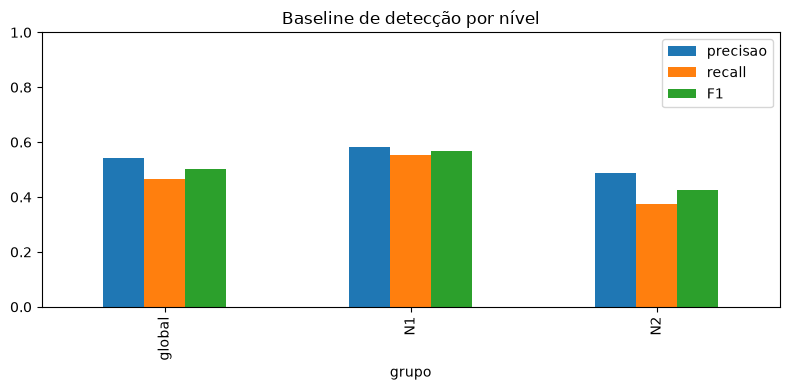

In [8]:
def span_iou(left_start: int, left_end: int, right_start: int, right_end: int) -> float:
    intersection = max(0, min(left_end, right_end) - max(left_start, right_start))
    union = max(left_end, right_end) - min(left_start, right_start)
    return intersection / union if union else 0.0

def greedy_match(gold_df: pd.DataFrame, pred_df: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    pairs = []
    for doc_id, gold_group in gold_df.groupby('documento_id'):
        pred_group = pred_df.loc[pred_df['documento_id'].eq(doc_id)]
        for gold_row in gold_group.itertuples():
            for pred_row in pred_group.itertuples():
                iou = span_iou(gold_row.inicio, gold_row.fim, pred_row.inicio, pred_row.fim)
                if iou >= threshold:
                    pairs.append({'gold_idx': gold_row.gold_idx, 'pred_idx': pred_row.pred_idx, 'iou': iou, 'exact': gold_row.inicio == pred_row.inicio and gold_row.fim == pred_row.fim})
    used_gold, used_pred, matches = set(), set(), []
    for pair in sorted(pairs, key=lambda item: (-item['iou'], item['gold_idx'], item['pred_idx'])):
        if pair['gold_idx'] not in used_gold and pair['pred_idx'] not in used_pred:
            matches.append(pair)
            used_gold.add(pair['gold_idx'])
            used_pred.add(pair['pred_idx'])
    return pd.DataFrame(matches, columns=['gold_idx', 'pred_idx', 'iou', 'exact'])

matches = greedy_match(citations, predictions)
matched_gold = set(matches['gold_idx'])
matched_pred = set(matches['pred_idx'])

def detector_metrics(name: str, gold_df: pd.DataFrame, pred_df: pd.DataFrame) -> dict:
    selected = matches.loc[matches['gold_idx'].isin(gold_df['gold_idx']) & matches['pred_idx'].isin(pred_df['pred_idx'])]
    tp = len(selected)
    fp = len(pred_df) - len(set(selected['pred_idx']))
    fn = len(gold_df) - len(set(selected['gold_idx']))
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    return {'grupo': name, 'TP': tp, 'FP': fp, 'FN': fn, 'precisao': precision, 'recall': recall, 'F1': 2 * precision * recall / (precision + recall) if precision + recall else 0.0, 'recall_IoU>=0.5': recall, 'recall_fronteira_exata': selected['exact'].mean() if len(gold_df) else 0.0}

metric_rows = [detector_metrics('global', citations, predictions)]
for level in ('N1', 'N2'):
    metric_rows.append(detector_metrics(level, citations[citations['nivel'].eq(level)], predictions[predictions['nivel'].eq(level)]))
for citation_type in sorted(citations['tipo'].unique()):
    metric_rows.append(detector_metrics(f'tipo:{citation_type}', citations[citations['tipo'].eq(citation_type)], predictions[predictions['tipo'].eq(citation_type)]))
for family in sorted(citations['family'].unique()):
    metric_rows.append(detector_metrics(f'familia:{family}', citations[citations['family'].eq(family)], predictions[predictions['family'].eq(family)]))
metrics = pd.DataFrame(metric_rows)
display(metrics.round(3))
metrics.loc[metrics['grupo'].isin(['global', 'N1', 'N2'])].plot.bar(x='grupo', y=['precisao', 'recall', 'F1'], ylim=(0, 1), figsize=(8, 4), title='Baseline de detecção por nível')
plt.tight_layout()


## 8. Falsos negativos, falsos positivos e fronteiras

As tabelas seguintes são a trilha de auditoria da baseline. Elas permitem ajustar regras de forma geral, sem exceções por documento ou por citação.

In [9]:
false_negatives = citations.loc[~citations['gold_idx'].isin(matched_gold)].copy()
false_negatives['contexto'] = false_negatives.apply(context_with_marker, axis=1)
false_positives = predictions.loc[~predictions['pred_idx'].isin(matched_pred)].copy()
false_positives['contexto'] = false_positives.apply(lambda row: f"{texts[row.documento_id][max(0, row.inicio - 100):row.inicio]}<CITAÇÃO>{row.text}</CITAÇÃO>{texts[row.documento_id][row.fim:row.fim + 100]}", axis=1)
boundary_matches = matches.merge(citations[['gold_idx', 'documento_id', 'inicio', 'fim', 'span_text', 'family']], on='gold_idx').merge(predictions[['pred_idx', 'inicio', 'fim', 'text', 'rule']], on='pred_idx', suffixes=('_gold', '_pred'))
boundary_matches['delta_inicio'] = boundary_matches['inicio_pred'] - boundary_matches['inicio_gold']
boundary_matches['delta_fim'] = boundary_matches['fim_pred'] - boundary_matches['fim_gold']

display(false_negatives[['documento_id', 'citacao_id', 'nivel', 'tipo', 'family', 'span_text', 'contexto']].head(30))
display(false_positives[['documento_id', 'nivel', 'rule', 'family', 'text', 'contexto']].head(30))
display(boundary_matches.loc[~boundary_matches['exact'], ['documento_id', 'family', 'rule', 'iou', 'delta_inicio', 'delta_fim', 'span_text', 'text']].head(30))


,documento_id,citacao_id,nivel,tipo,family,span_text,contexto
0,gen_n1_001,g1,N1,lei,lei_referencia_geral,normas\nde regência da matéria,s\nà espécie.\n\n\nA questão de fundo comporta solução singela. Toda a construção defensiva repousa nas <CITAÇÃO>normas\nde regência da ...
1,gen_n1_001,g2,N1,jurisprudencia,jurisprudencia_tribunal_contextual,julgado do STF proferido em 2024 pela relatoria de Dias Toffoli,"a matéria. Registre-se que o tema comporta enfrentamento sob dupla perspectiva.\nInvoca-se, ainda, o <CITAÇÃO>julgado do STF proferido e..."
4,gen_n1_001,g5,N1,jurisprudencia,jurisprudencia_tribunal_contextual,julgado do STM proferido em 2023\npela relatoria de CARLOS AUGUSTO AMARAL OLIVEIRA,r. A leitura conjunta dos dispositivos\ninvocados conduz à mesma conclusão. Como já se reconheceu no <CITAÇÃO>julgado do STM proferido e...
6,gen_n1_001,g7,N1,lei,lei_referencia_geral,dispositivo constitucional invocado na origem,"b outro ângulo, a solução adotada na origem afronta a segurança\njurídica. Impõe-se a observância do <CITAÇÃO>dispositivo constitucional..."
8,gen_n1_001,g9,N1,jurisprudencia,jurisprudencia_tribunal_contextual,"precedente do STM de 2023, da relatoria de Marco Antonio","ue\nassim não fosse, subsiste fundamento autônomo a amparar a pretensão. A tese encontra respaldo\nno <CITAÇÃO>precedente do STM de 2023..."
10,gen_n1_002,g1,N1,jurisprudencia,jurisprudencia_tribunal_contextual,"precedente\ndo STF de 2026, da relatoria de CRISTIANO ZANIN",usos. Decido.\n\n\nA parte contrária limita-se a repisar argumentos já superados. Como se depreende do <CITAÇÃO>precedente\ndo STF de 20...
11,gen_n1_002,g2,N1,jurisprudencia,processo_ou_recurso_numerado,"Reclamação\ndo STF, de 2025, Rel. Min. CRISTIANO ZANIN","aminada.\nCumpre observar que a orientação dos tribunais superiores é firme no ponto. Vale invocar a <CITAÇÃO>Reclamação\ndo STF, de 202..."
17,gen_n1_002,g8,N1,lei,lei_referencia_geral,dispositivo constitucional\ninvocado na origem,"ram origem à demanda. Antes\nde avançar, convém delimitar o objeto da irresignação. Cumpre lembrar o <CITAÇÃO>dispositivo constitucional..."
18,gen_n1_002,g9,N1,lei,lei_dispositivo_com_diploma,art. 1.134 da Lei nº\n13.105/2015,de mora a partir da citação.\nA questão de fundo comporta solução singela. Impõe-se a observância do <CITAÇÃO>art. 1.134 da Lei nº\n13.1...
20,gen_n1_003,g2,N1,jurisprudencia,jurisprudencia_referencia_geral,jurisprudência pacífica desta Corte,"dade\nprevista no instrumento. Não se trata, aqui, de revolver matéria fática. Reforça o argumento\na <CITAÇÃO>jurisprudência pacífica d..."


,documento_id,nivel,rule,family,text,contexto
0,gen_n1_001,N1,cnj,processo_cnj,1292746-27.2020.7.13.1173,DEFENSORIA PÚBLICA DA UNIÃO\nOFÍCIO JUNTO AO SUPERIOR TRIBUNAL MILITAR\n\nProcesso nº <CITAÇÃO>1292746-27.2020.7.13.1173</CITAÇÃO>\nAssi...
1,gen_n1_001,N1,tribunal_contextual,jurisprudencia_tribunal_contextual,STF proferido em 2024,"Registre-se que o tema comporta enfrentamento sob dupla perspectiva.\nInvoca-se, ainda, o julgado do <CITAÇÃO>STF proferido em 2024</CIT..."
4,gen_n1_001,N1,tribunal_contextual,jurisprudencia_tribunal_contextual,STM proferido em 2023,a conjunta dos dispositivos\ninvocados conduz à mesma conclusão. Como já se reconheceu no julgado do <CITAÇÃO>STM proferido em 2023</CIT...
7,gen_n1_001,N1,tribunal_contextual,jurisprudencia_tribunal_contextual,STM de 2023,"osse, subsiste fundamento autônomo a amparar a pretensão. A tese encontra respaldo\nno precedente do <CITAÇÃO>STM de 2023</CITAÇÃO>, da ..."
9,gen_n1_002,N1,cnj,processo_cnj,6706918-56.2019.4.17.3043,IONAL FEDERAL DA PRIMEIRA REGIÃO\nGABINETE DO DESEMBARGADOR FEDERAL OTÁVIO LINS PEREIRA\n\nProcesso nº <CITAÇÃO>6706918-56.2019.4.17.304...
10,gen_n1_002,N1,tribunal_contextual,jurisprudencia_tribunal_contextual,STF de 2026,"\n\nA parte contrária limita-se a repisar argumentos já superados. Como se depreende do precedente\ndo <CITAÇÃO>STF de 2026</CITAÇÃO>, d..."
11,gen_n1_002,N1,tribunal_contextual,jurisprudencia_tribunal_contextual,"STF, de 2025","e observar que a orientação dos tribunais superiores é firme no ponto. Vale invocar a Reclamação\ndo <CITAÇÃO>STF, de 2025</CITAÇÃO>, Re..."
17,gen_n1_002,N1,dispositivo_legal,lei_dispositivo_sem_diploma,art. 1,de mora a partir da citação.\nA questão de fundo comporta solução singela. Impõe-se a observância do <CITAÇÃO>art. 1</CITAÇÃO>.134 da Le...
18,gen_n1_003,N1,cnj,processo_cnj,8416083-51.2022.3.07.4978,EGRÉGIO SUPERIOR TRIBUNAL DE JUSTIÇA\n\nAutos nº <CITAÇÃO>8416083-51.2022.3.07.4978</CITAÇÃO>\nRecorrente: CARLOS EDUARDO MARQUES\nRecor...
20,gen_n1_003,N1,dispositivo_legal,lei_dispositivo_sem_diploma,art. 158,ente conhecida no foro. Os elementos coligidos\naos autos apontam em sentido único. Cumpre lembrar o <CITAÇÃO>art. 158</CITAÇÃO> do Códi...


,documento_id,family,rule,iou,delta_inicio,delta_fim,span_text,text
19,gen_n2_004,lei_dispositivo_com_diploma,lei_com_diploma,0.968750,0,1,artigo 172 da Lei nº 9.504/1997,artigo 172 da Lei nº 9.504/1997.
20,gen_n2_005,lei_dispositivo_com_diploma,lei_com_diploma,0.965517,0,1,art 60 da Lei nº 13.467/2017,art 60 da Lei nº 13.467/2017.
21,gen_n1_005,processo_ou_recurso_numerado,processo_ou_recurso,0.926829,0,-3,AgInt no Recurso\nEspecial nº 1.620.021/PR,AgInt no Recurso\nEspecial nº 1.620.021
22,gen_n1_010,processo_ou_recurso_numerado,processo_ou_recurso,0.906250,0,-3,Recurso Especial nº 1.657.496/RS,Recurso Especial nº 1.657.496
23,gen_n1_010,processo_ou_recurso_numerado,processo_ou_recurso,0.906250,0,-3,Recurso Especial nº 1.718.894/SP,Recurso Especial nº 1.718.894
24,gen_n1_002,processo_ou_recurso_numerado,processo_ou_recurso,0.900000,0,-3,AgInt no AREsp nº 1.996.496/RJ,AgInt no AREsp nº 1.996.496
25,gen_n1_010,processo_ou_recurso_numerado,processo_ou_recurso,0.896552,0,-3,AgInt no REsp nº 1.944.552/RS,AgInt no REsp nº 1.944.552
26,gen_n1_003,processo_ou_recurso_numerado,processo_ou_recurso,0.884615,0,-3,AgRg no AREsp 1.327.863/PR,AgRg no AREsp 1.327.863
27,gen_n1_005,processo_ou_recurso_numerado,processo_ou_recurso,0.884615,0,-3,AgInt no REsp 1.599.910/PR,AgInt no REsp 1.599.910
28,gen_n1_005,processo_ou_recurso_numerado,processo_ou_recurso,0.884615,0,-3,AgInt no REsp 1.664.893/PR,AgInt no REsp 1.664.893


## 9. Parsing experimental com spans-oráculo

Para separar a dificuldade de detectar da de estruturar, o parser abaixo recebe somente os spans anotados. Ele extrai tribunal, classe, número e UF apenas quando aparecem de forma explícita; não corrige OCR nem faz inferência de identidade.

In [10]:
TRIBUNAL_PATTERNS = (('STF', re.compile(r'\b(?:STF|Supremo Tribunal Federal)\b', re.I)), ('STJ', re.compile(r'\b(?:STJ|Superior Tribunal de Justiça)\b', re.I)), ('TSE', re.compile(r'\b(?:TSE|Tribunal Superior Eleitoral)\b', re.I)), ('TST', re.compile(r'\b(?:TST|Tribunal Superior do Trabalho)\b', re.I)), ('STM', re.compile(r'\b(?:STM|Superior Tribunal Militar)\b', re.I)))
NUMBER_RE = re.compile(r'\b\d{1,7}(?:\s*[.-]\s*\d{1,7}){1,}(?:\s*-\s*[A-Z]{2})?\b')
CLASS_RE = re.compile(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|S[ÚU]mula|Agravo(?: Regimental)?|Recurso Especial|Recurso Extraordin[aá]rio|Habeas Corpus|Reclamaç[aã]o)\b', re.I)

def parse_oracle_span(text: str) -> dict:
    tribunal_raw = tribunal_normalizado = None
    for normalized, pattern in TRIBUNAL_PATTERNS:
        match = pattern.search(text)
        if match:
            tribunal_raw, tribunal_normalizado = match.group(0), normalized
            break
    class_match = CLASS_RE.search(text)
    number_match = CNJ_RE.search(text) or NUMBER_RE.search(text)
    uf_match = re.search(r'[-/]\s*([A-Z]{2})\b', text)
    numero_raw = number_match.group(0) if number_match else None
    numero_normalizado = re.sub(r'\D', '', numero_raw) if numero_raw else None
    number_family = 'cnj' if numero_raw and CNJ_RE.fullmatch(numero_raw) else ('numero_pontuado_ou_recurso' if numero_raw else None)
    return {'tribunal_raw': tribunal_raw, 'tribunal_normalizado': tribunal_normalizado, 'class_raw': class_match.group(0) if class_match else None, 'numero_raw': numero_raw, 'numero_normalizado': numero_normalizado, 'uf_raw': uf_match.group(1) if uf_match else None, 'number_family': number_family}

oracle_parsed = pd.concat([citations[['gold_idx', 'documento_id', 'citacao_id', 'nivel', 'tipo', 'classificacao', 'family', 'span_text']].reset_index(drop=True), pd.DataFrame(citations['span_text'].map(parse_oracle_span).tolist())], axis=1)
oracle_parsed['tem_numero'] = oracle_parsed['numero_normalizado'].notna()
oracle_parsed['tem_tribunal_explicito'] = oracle_parsed['tribunal_normalizado'].notna()
oracle_parsed['tem_classe'] = oracle_parsed['class_raw'].notna()
display(oracle_parsed.head(20))
parser_coverage = oracle_parsed.groupby('family').agg(total=('gold_idx', 'size'), tribunal_explicito=('tem_tribunal_explicito', 'mean'), classe=('tem_classe', 'mean'), numero=('tem_numero', 'mean'), uf=('uf_raw', 'count')).reset_index()
display(parser_coverage.round(3))


,gold_idx,documento_id,citacao_id,nivel,tipo,classificacao,family,span_text,tribunal_raw,tribunal_normalizado,class_raw,numero_raw,numero_normalizado,uf_raw,number_family,tem_numero,tem_tribunal_explicito,tem_classe
0,0,gen_n1_001,g1,N1,lei,incompleta,lei_referencia_geral,normas\nde regência da matéria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,1,gen_n1_001,g2,N1,jurisprudencia,incompleta,jurisprudencia_tribunal_contextual,julgado do STF proferido em 2024 pela relatoria de Dias Toffoli,STF,STF,NaN,NaN,NaN,NaN,NaN,False,True,False
2,2,gen_n1_001,g3,N1,jurisprudencia,inventada,processo_ou_recurso_numerado,Reclamação nº 66.516/RO,NaN,NaN,Reclamação,66.516,66516,RO,numero_pontuado_ou_recurso,True,False,True
3,3,gen_n1_001,g4,N1,jurisprudencia,inventada,processo_cnj,AgInt 7557430-50.2018.7.00.0000/DF,NaN,NaN,AgInt,7557430-50.2018.7.00.0000,75574305020187000000,DF,cnj,True,False,True
4,4,gen_n1_001,g5,N1,jurisprudencia,incompleta,jurisprudencia_tribunal_contextual,julgado do STM proferido em 2023\npela relatoria de CARLOS AUGUSTO AMARAL OLIVEIRA,STM,STM,NaN,NaN,NaN,NaN,NaN,False,True,False
5,5,gen_n1_001,g6,N1,jurisprudencia,real,processo_cnj,APL nº\n7000449-40.2023.7.00.0000/RS,NaN,NaN,NaN,7000449-40.2023.7.00.0000,70004494020237000000,RS,cnj,True,False,False
6,6,gen_n1_001,g7,N1,lei,incompleta,lei_referencia_geral,dispositivo constitucional invocado na origem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
7,7,gen_n1_001,g8,N1,jurisprudencia,inventada,processo_ou_recurso_numerado,Rcl 88.178/RS,NaN,NaN,Rcl,88.178,88178,RS,numero_pontuado_ou_recurso,True,False,True
8,8,gen_n1_001,g9,N1,jurisprudencia,incompleta,jurisprudencia_tribunal_contextual,"precedente do STM de 2023, da relatoria de Marco Antonio",STM,STM,NaN,NaN,NaN,NaN,NaN,False,True,False
9,9,gen_n1_001,g10,N1,jurisprudencia,real,processo_cnj,RSE nº 7000592-58.2025.7.00.0000/DF,NaN,NaN,NaN,7000592-58.2025.7.00.0000,70005925820257000000,DF,cnj,True,False,False


,family,total,tribunal_explicito,classe,numero,uf
0,jurisprudencia_referencia_geral,46,0.087,0.0,0.217,13
1,jurisprudencia_tribunal_contextual,20,1.000,0.0,0.000,0
2,lei_dispositivo_com_diploma,27,0.000,0.0,0.222,0
3,lei_dispositivo_sem_diploma,1,0.000,0.0,0.000,0
4,lei_referencia_geral,11,0.000,0.0,0.000,0
5,processo_cnj,25,0.280,0.4,1.000,15
6,processo_ou_recurso_numerado,85,0.082,1.0,0.565,63
7,sumula_numerada,10,0.700,1.0,0.000,0


## 10. Estrutura, rótulos e síntese

Os rótulos são cruzados com famílias somente depois da taxonomia e do parsing. Assim, o notebook evidencia quais formas aparecem em cada rótulo sem usar o rótulo como atalho para detectar, parsear ou resolver.

In [11]:
display(pd.crosstab(citations['family'], citations['classificacao'], margins=True))
family_detector = metrics.loc[metrics['grupo'].str.startswith('familia:'), ['grupo', 'recall']].copy()
family_detector['family'] = family_detector['grupo'].str.removeprefix('familia:')
family_summary = family_summary.merge(family_detector[['family', 'recall']], on='family', how='left').rename(columns={'recall': 'detector_recall'})
family_summary = family_summary.merge(parser_coverage[['family', 'numero']].rename(columns={'numero': 'oracle_parser_coverage'}), on='family', how='left')
family_summary = family_summary[['family', 'count', 'N1', 'N2', 'real', 'inventada', 'incompleta', 'detector_recall', 'oracle_parser_coverage']].sort_values('count', ascending=False)
display(family_summary.round(3))

global_metrics = metrics.loc[metrics['grupo'].eq('global')].iloc[0]
print(f"Detector: TP={int(global_metrics.TP)}, FP={int(global_metrics.FP)}, FN={int(global_metrics.FN)}, precisão={global_metrics.precisao:.3f}, recall={global_metrics.recall:.3f}, F1={global_metrics.F1:.3f}.")
print('Parsing-oráculo: extração explícita; ausência de número ou tribunal não é preenchida por inferência.')


classificacao,incompleta,inventada,real,All
family,,,,
jurisprudencia_referencia_geral,23,10,13,46
jurisprudencia_tribunal_contextual,20,0,0,20
lei_dispositivo_com_diploma,0,14,13,27
lei_dispositivo_sem_diploma,0,0,1,1
lei_referencia_geral,11,0,0,11
processo_cnj,0,2,23,25
processo_ou_recurso_numerado,11,32,42,85
sumula_numerada,0,6,4,10
All,65,64,96,225


,family,count,N1,N2,real,inventada,incompleta,detector_recall,oracle_parser_coverage
2,processo_ou_recurso_numerado,85,46,39,42,32,11,0.659,0.565
6,jurisprudencia_referencia_geral,46,15,31,13,10,23,0.000,0.217
5,lei_dispositivo_com_diploma,27,13,14,13,14,0,0.556,0.222
3,processo_cnj,25,17,8,23,2,0,0.760,1.000
1,jurisprudencia_tribunal_contextual,20,11,9,0,0,20,0.000,0.000
0,lei_referencia_geral,11,7,4,0,0,11,0.000,0.000
4,sumula_numerada,10,6,4,4,6,0,1.000,0.000
7,lei_dispositivo_sem_diploma,1,1,0,1,0,0,0.000,0.000


Detector: TP=105, FP=89, FN=120, precisão=0.541, recall=0.467, F1=0.501.
Parsing-oráculo: extração explícita; ausência de número ou tribunal não é preenchida por inferência.


## 11. Falhas, implicações e conclusão

- O baseline de detecção é uma régua interpretável, não um componente de produção. FN, FP e fronteiras devem orientar regras gerais, nunca exceções por documento.
- N2 pode combinar quebras, espaços e separadores degradados; os indícios exibidos são contextuais e não autorizam reparos especulativos.
- O parsing com spans-oráculo isola o que a forma textual torna explícito. Ele não determina `id_canonico`, não escolhe candidatos e não é um resolver.
- Antes de qualquer arquitetura de resolução, o próximo experimento deve melhorar a detecção e medir fronteiras por família, preservando o contrato de saída e a separação entre detecção, parsing e resolução.

## 12. Integridade do banco

O notebook não abre o SQLite para escrita. A soma abaixo confirma que o arquivo canônico permaneceu idêntico durante a exploração.

In [12]:
db_sha_after = sha256_file(DB_PATH)
print(f'SHA-256 do SQLite (depois): {db_sha_after}')
assert db_sha_before == db_sha_after == 'd759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71'
print('Integridade do arquivo SQLite preservada.')


SHA-256 do SQLite (depois): d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71
Integridade do arquivo SQLite preservada.
